In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fsm_ds = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge_ds = xr.open_dataset("../data/processed/senorge_all.nc")
snowpack_ds = xr.open_dataset("../data/processed/snowpack_all.nc")

print("FSM vars:", list(fsm_ds.data_vars))
print("seNorge vars:", list(senorge_ds.data_vars))
print("Snow vars:", list(snowpack_ds.data_vars))

FSM vars: ['snow_depth', 'UTM_Zone_33']
seNorge vars: ['snow_depth', 'projection_info', 'UTM_Zone_33', 'snow_water_equivalent']
Snow vars: ['Qs', 'Ql', 'Qg', 'TSG', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'OLWR', 'ILWR', 'LWR_net', 'RSWR', 'ISWR', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TA', 'TSS_mod', 'TSS_meas', 'T_bottom', 'RH', 'VW', 'VW_drift', 'DW', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5']


In [2]:
fsm_sd = fsm_ds["snow_depth"] / 1000.0
senorge_sd = senorge_ds["snow_depth"] / 100.0
snowpack_sd = snowpack_ds["HS_mod"] / 100.0

In [3]:
fsm_sd.attrs["units"] = "m"
senorge_sd.attrs["units"] = "m"
snowpack_sd.attrs["units"] = "m"

In [4]:
def get_aligned_station_series(station_id, snowpack_sd, fsm_sd, senorge_sd):
    snowpack_point = snowpack_sd.sel(station=station_id)

    x0 = float(snowpack_point["x"].values)
    y0 = float(snowpack_point["y"].values)

    snowpack_ts = snowpack_point.resample(time="1D").mean()
    fsm_ts = fsm_sd.sel(x=x0, y=y0, method="nearest")
    senorge_ts = senorge_sd.sel(x=x0, y=y0, method="nearest")

    snowpack_ts, fsm_ts = xr.align(snowpack_ts, fsm_ts, join="inner")
    snowpack_ts, senorge_ts = xr.align(snowpack_ts, senorge_ts, join="inner")

    return snowpack_ts, fsm_ts, senorge_ts

In [5]:
def metrics(model, reference):
    model, reference = xr.align(model, reference, join="inner")

    valid = np.isfinite(model) & np.isfinite(reference)
    model = model.where(valid, drop=True)
    reference = reference.where(valid, drop=True)

    n = model.size
    if n == 0:
        return np.nan, np.nan, np.nan

    diff = model - reference
    bias = float(diff.mean().values)
    rmse = float(np.sqrt((diff ** 2).mean().values))

    if n < 2:
        corr = np.nan
    else:
        corr = float(xr.corr(model, reference, dim="time").values)

    return bias, rmse, corr

In [6]:
def plot_station_timeseries(station_id, snowpack_ts, fsm_ts, senorge_ts):
    plt.figure(figsize=(10, 5))
    snowpack_ts.plot(label="SNOWPACK", linewidth=2.5)
    fsm_ts.plot(label="FSM2", linewidth=2)
    senorge_ts.plot(label="seNorge", linewidth=2)

    plt.title(f"Snow depth comparison at station {station_id}")
    plt.ylabel("Snow depth [m]")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

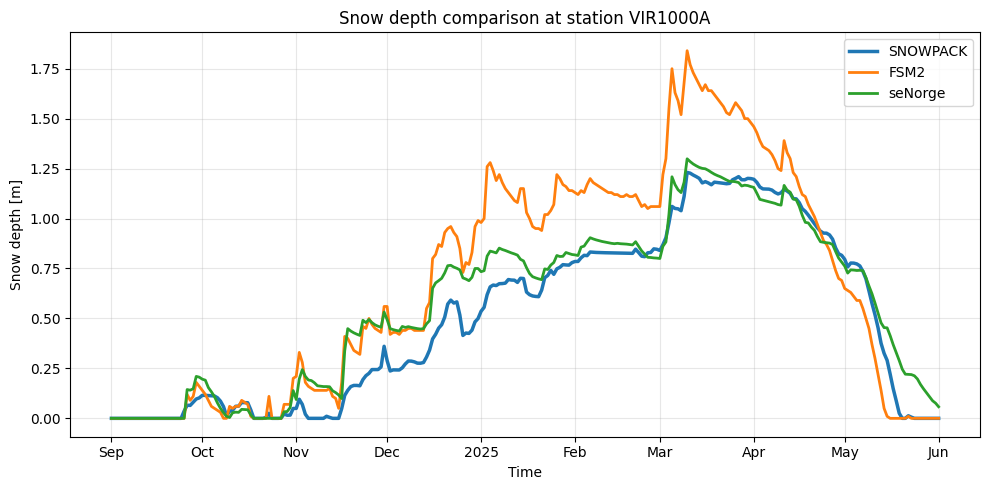

FSM2 vs SNOWPACK
Bias: 0.17746241690386963
RMSE: 0.2700195402344719
Corr: 0.9506447364711808

seNorge vs SNOWPACK
Bias: 0.07422155229245532
RMSE: 0.12163537711466287
Corr: 0.974486781070452


In [7]:
station_id = "VIR1000A"
snowpack_ts, fsm_ts, senorge_ts = get_aligned_station_series(
    station_id, snowpack_sd, fsm_sd, senorge_sd
)

plot_station_timeseries(station_id, snowpack_ts, fsm_ts, senorge_ts)

bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, snowpack_ts)
bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, snowpack_ts)

print("FSM2 vs SNOWPACK")
print("Bias:", bias_fsm)
print("RMSE:", rmse_fsm)
print("Corr:", corr_fsm)

print("\nseNorge vs SNOWPACK")
print("Bias:", bias_sen)
print("RMSE:", rmse_sen)
print("Corr:", corr_sen)

In [8]:
results = []

station_ids = snowpack_ds["station"].values

for station_id in station_ids:
    try:
        snowpack_ts, fsm_ts, senorge_ts = get_aligned_station_series(
            station_id, snowpack_sd, fsm_sd, senorge_sd
        )

        if len(snowpack_ts.time) < 30:
            continue

        bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, snowpack_ts)
        bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, snowpack_ts)

        results.append({
            "station": str(station_id),
            "elev": float(snowpack_ds["elev"].sel(station=station_id).values),
            "lon": float(snowpack_ds["lon"].sel(station=station_id).values),
            "lat": float(snowpack_ds["lat"].sel(station=station_id).values),
            "bias_fsm": bias_fsm,
            "rmse_fsm": rmse_fsm,
            "corr_fsm": corr_fsm,
            "bias_senorge": bias_sen,
            "rmse_senorge": rmse_sen,
            "corr_senorge": corr_sen
        })

    except Exception as e:
        print(f"Feil på {station_id}: {e}")

results_df = pd.DataFrame(results)

In [9]:
results_df.to_csv("../data/processed/model_comparison_metrics.csv", index=False)

In [10]:
print(results_df.shape)
print(results_df.head())
print(results_df.describe())
print(results_df.isna().sum())

(4484, 10)
  station    elev       lon        lat  bias_fsm  rmse_fsm  corr_fsm  \
0   VIR1A  1410.0  7.427735  61.843654  0.410240  0.485793  0.983633   
1   VIR2A  1687.0  7.425528  61.852553  0.103905  0.302574  0.981410   
2   VIR3A  1617.0  7.423319  61.861451  0.120437  0.326459  0.979301   
3   VIR6A  1031.0  7.416682  61.888146  0.482669  0.584852  0.978773   
4   VIR7A  1465.0  7.414468  61.897044  0.645801  0.758771  0.980729   

   bias_senorge  rmse_senorge  corr_senorge  
0      0.488109      0.606686      0.982387  
1      0.298245      0.379309      0.986499  
2      0.076710      0.203470      0.991330  
3      0.532129      0.679242      0.912726  
4      1.074038      1.268303      0.945473  
              elev          lon          lat     bias_fsm     rmse_fsm  \
count  4484.000000  4484.000000  4484.000000  4484.000000  4484.000000   
mean   1337.855932     8.178508    61.537326     0.124198     0.294600   
std     344.345936     0.327717     0.262909     0.182984 

In [11]:
summary_df = pd.DataFrame({
    "FSM2": [
        results_df["bias_fsm"].mean(),
        results_df["rmse_fsm"].mean(),
        results_df["corr_fsm"].mean(),
        results_df["bias_fsm"].median(),
        results_df["rmse_fsm"].median(),
        results_df["corr_fsm"].median(),
    ],
    "seNorge": [
        results_df["bias_senorge"].mean(),
        results_df["rmse_senorge"].mean(),
        results_df["corr_senorge"].mean(),
        results_df["bias_senorge"].median(),
        results_df["rmse_senorge"].median(),
        results_df["corr_senorge"].median(),
    ]
}, index=[
    "Mean bias", "Mean RMSE", "Mean corr",
    "Median bias", "Median RMSE", "Median corr"
])

print(summary_df)

                 FSM2   seNorge
Mean bias    0.124198  0.081897
Mean RMSE    0.294600  0.376439
Mean corr    0.948760  0.942712
Median bias  0.127905  0.063151
Median RMSE  0.280747  0.288720
Median corr  0.967743  0.971626


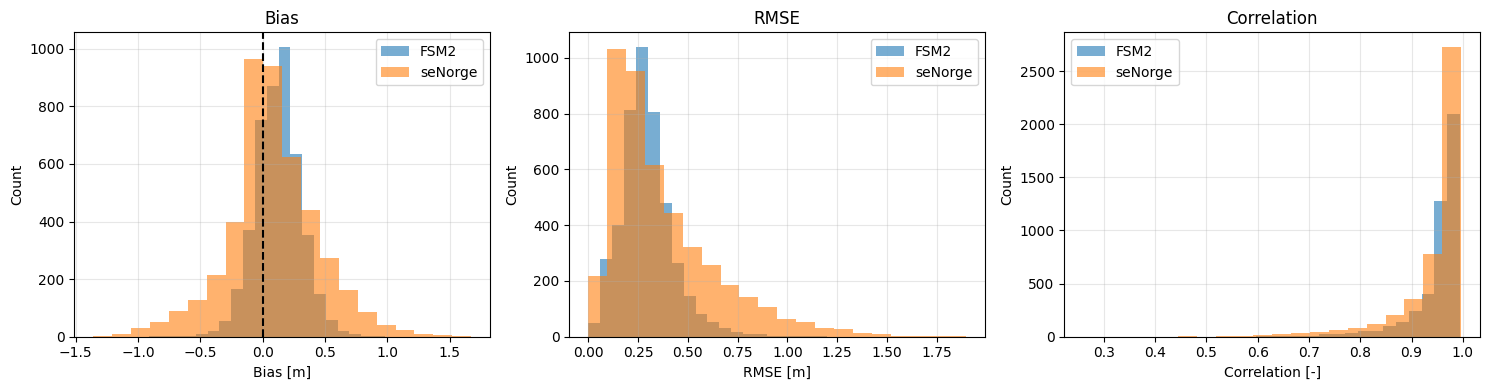

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(results_df["bias_fsm"].dropna(), bins=20, alpha=0.6, label="FSM2")
axes[0].hist(results_df["bias_senorge"].dropna(), bins=20, alpha=0.6, label="seNorge")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Bias")
axes[0].set_xlabel("Bias [m]")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(results_df["rmse_fsm"].dropna(), bins=20, alpha=0.6, label="FSM2")
axes[1].hist(results_df["rmse_senorge"].dropna(), bins=20, alpha=0.6, label="seNorge")
axes[1].set_title("RMSE")
axes[1].set_xlabel("RMSE [m]")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(results_df["corr_fsm"].dropna(), bins=20, alpha=0.6, label="FSM2")
axes[2].hist(results_df["corr_senorge"].dropna(), bins=20, alpha=0.6, label="seNorge")
axes[2].set_title("Correlation")
axes[2].set_xlabel("Correlation [-]")
axes[2].set_ylabel("Count")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_85542/230055421.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_85542/230055421.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_85542/230055421.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


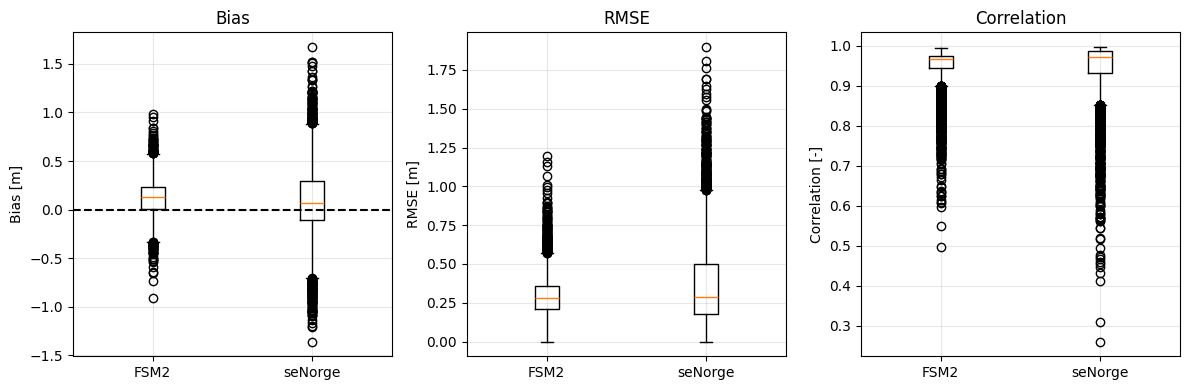

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].boxplot(
    [results_df["bias_fsm"].dropna(), results_df["bias_senorge"].dropna()],
    labels=["FSM2", "seNorge"]
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Bias")
axes[0].set_ylabel("Bias [m]")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(
    [results_df["rmse_fsm"].dropna(), results_df["rmse_senorge"].dropna()],
    labels=["FSM2", "seNorge"]
)
axes[1].set_title("RMSE")
axes[1].set_ylabel("RMSE [m]")
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(
    [results_df["corr_fsm"].dropna(), results_df["corr_senorge"].dropna()],
    labels=["FSM2", "seNorge"]
)
axes[2].set_title("Correlation")
axes[2].set_ylabel("Correlation [-]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

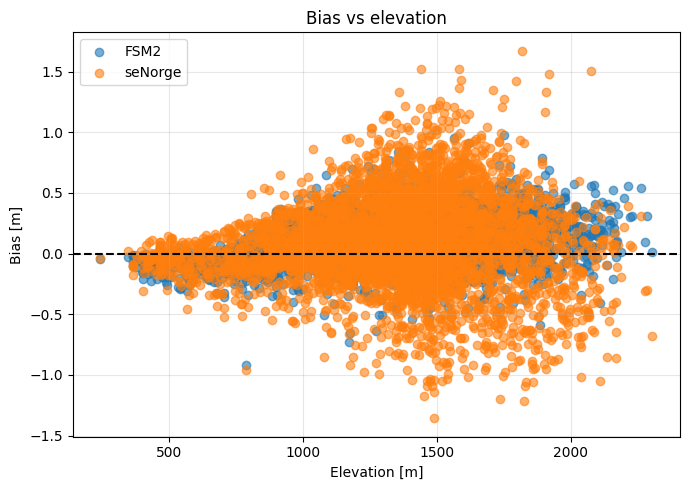

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(results_df["elev"], results_df["bias_fsm"], alpha=0.6, label="FSM2")
plt.scatter(results_df["elev"], results_df["bias_senorge"], alpha=0.6, label="seNorge")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Elevation [m]")
plt.ylabel("Bias [m]")
plt.title("Bias vs elevation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

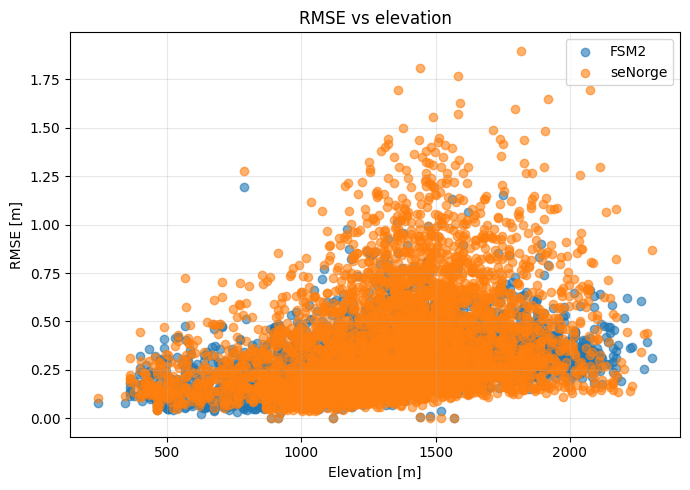

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(results_df["elev"], results_df["rmse_fsm"], alpha=0.6, label="FSM2")
plt.scatter(results_df["elev"], results_df["rmse_senorge"], alpha=0.6, label="seNorge")
plt.xlabel("Elevation [m]")
plt.ylabel("RMSE [m]")
plt.title("RMSE vs elevation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

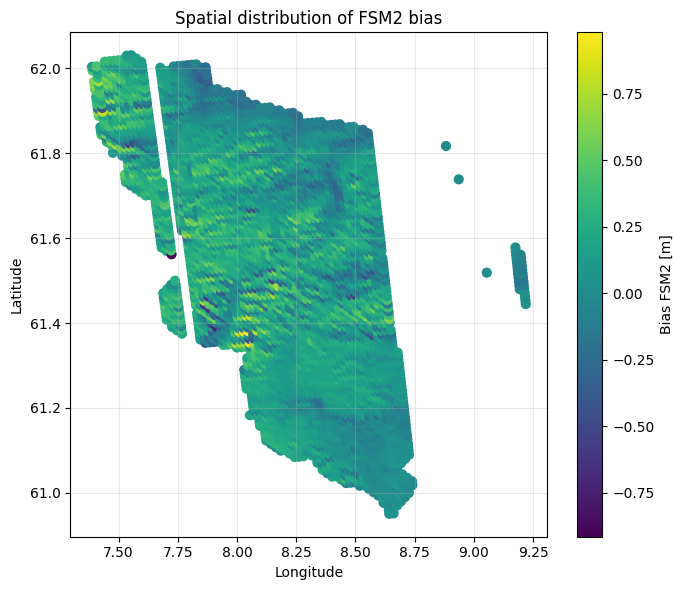

In [16]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    results_df["lon"],
    results_df["lat"],
    c=results_df["bias_fsm"],
    s=40
)
plt.colorbar(sc, label="Bias FSM2 [m]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial distribution of FSM2 bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

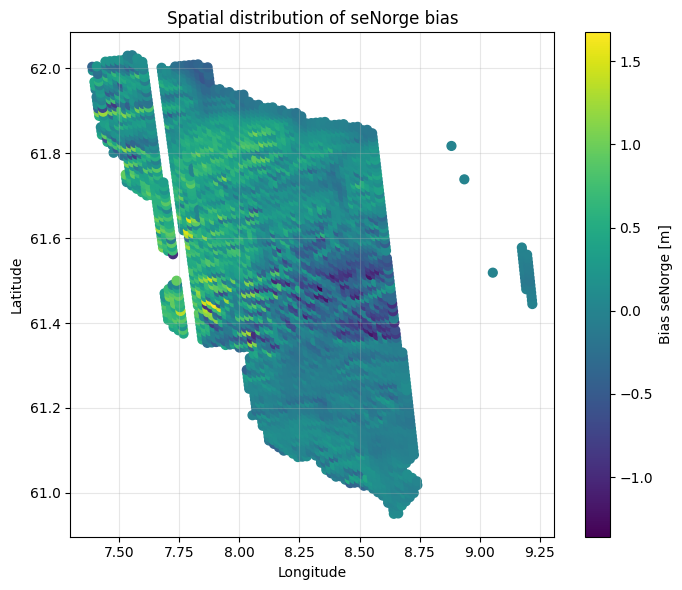

In [17]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    results_df["lon"],
    results_df["lat"],
    c=results_df["bias_senorge"],
    s=40
)
plt.colorbar(sc, label="Bias seNorge [m]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial distribution of seNorge bias")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

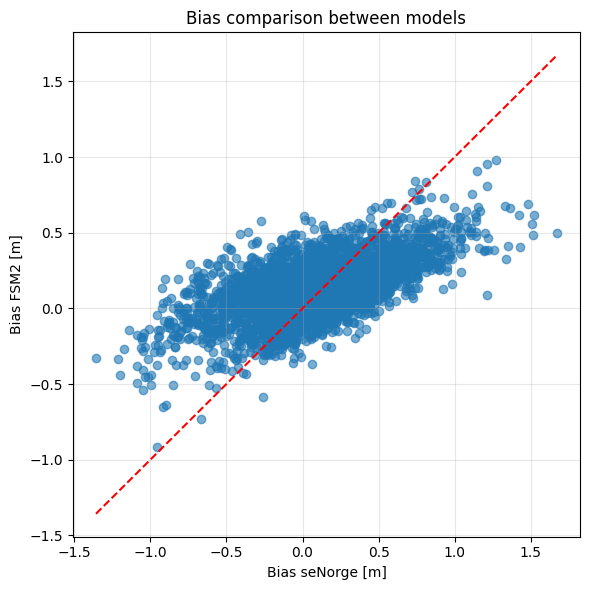

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(results_df["bias_senorge"], results_df["bias_fsm"], alpha=0.6)

lims = [
    min(results_df["bias_senorge"].min(), results_df["bias_fsm"].min()),
    max(results_df["bias_senorge"].max(), results_df["bias_fsm"].max())
]
plt.plot(lims, lims, "r--")

plt.xlabel("Bias seNorge [m]")
plt.ylabel("Bias FSM2 [m]")
plt.title("Bias comparison between models")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

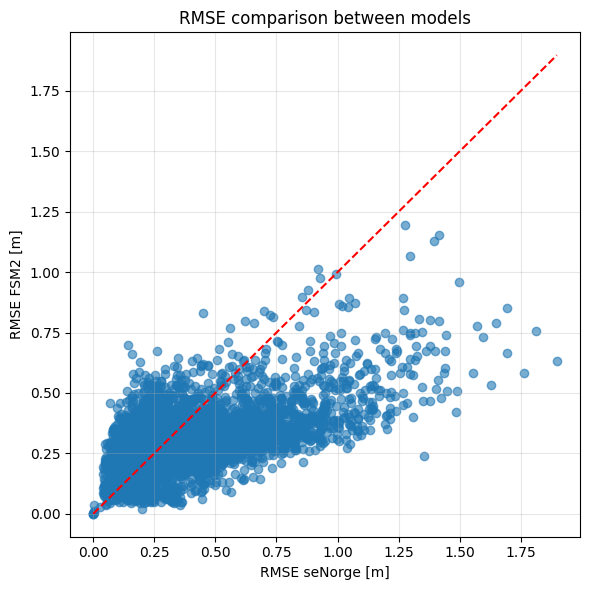

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(results_df["rmse_senorge"], results_df["rmse_fsm"], alpha=0.6)

lims = [
    min(results_df["rmse_senorge"].min(), results_df["rmse_fsm"].min()),
    max(results_df["rmse_senorge"].max(), results_df["rmse_fsm"].max())
]
plt.plot(lims, lims, "r--")

plt.xlabel("RMSE seNorge [m]")
plt.ylabel("RMSE FSM2 [m]")
plt.title("RMSE comparison between models")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
results_df["best_model_rmse"] = np.where(
    results_df["rmse_fsm"] < results_df["rmse_senorge"],
    "FSM2",
    "seNorge"
)

print(results_df["best_model_rmse"].value_counts())

best_model_rmse
FSM2       2577
seNorge    1907
Name: count, dtype: int64


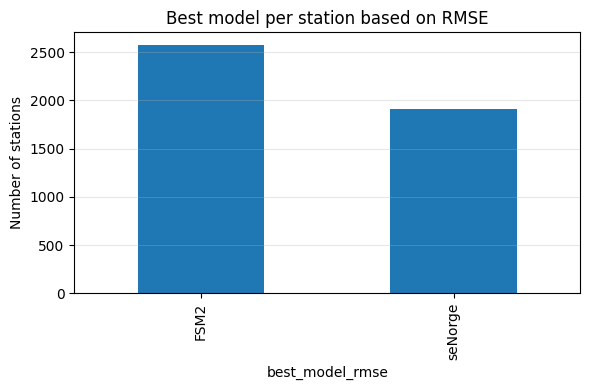

In [21]:
results_df["best_model_rmse"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.ylabel("Number of stations")
plt.title("Best model per station based on RMSE")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
results_df["best_model_abs_bias"] = np.where(
    results_df["bias_fsm"].abs() < results_df["bias_senorge"].abs(),
    "FSM2",
    "seNorge"
)

print(results_df["best_model_abs_bias"].value_counts())

best_model_abs_bias
FSM2       2829
seNorge    1655
Name: count, dtype: int64


In [24]:
def plot_station_timeseries(station_id, snowpack_ts, fsm_ts, senorge_ts):
    bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, snowpack_ts)
    bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, snowpack_ts)

    plt.figure(figsize=(11, 5))
    snowpack_ts.plot(label="SNOWPACK", linewidth=2.5)
    fsm_ts.plot(label="FSM2", linewidth=2)
    senorge_ts.plot(label="seNorge", linewidth=2)

    textstr = (
        f"FSM2: bias={bias_fsm:.2f}, RMSE={rmse_fsm:.2f}, corr={corr_fsm:.2f}\n"
        f"seNorge: bias={bias_sen:.2f}, RMSE={rmse_sen:.2f}, corr={corr_sen:.2f}"
    )

    plt.text(
        0.02, 0.98, textstr,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.title(f"Snow depth comparison at station {station_id}")
    plt.ylabel("Snow depth [m]")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
def inspect_station(station_id, snowpack_sd, fsm_sd, senorge_sd):
    snowpack_ts, fsm_ts, senorge_ts = get_aligned_station_series(
        station_id, snowpack_sd, fsm_sd, senorge_sd
    )

    print(f"\nStation: {station_id}")
    print("SNOWPACK max:", float(snowpack_ts.max()))
    print("FSM2 max:", float(fsm_ts.max()))
    print("seNorge max:", float(senorge_ts.max()))

    bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, snowpack_ts)
    bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, snowpack_ts)

    print("\nFSM2 vs SNOWPACK")
    print("Bias:", bias_fsm)
    print("RMSE:", rmse_fsm)
    print("Corr:", corr_fsm)

    print("\nseNorge vs SNOWPACK")
    print("Bias:", bias_sen)
    print("RMSE:", rmse_sen)
    print("Corr:", corr_sen)

    plot_station_timeseries(station_id, snowpack_ts, fsm_ts, senorge_ts)


Station: VIR1000A
SNOWPACK max: 1.2310125
FSM2 max: 1.840000033378601
seNorge max: 1.2990001440048218

FSM2 vs SNOWPACK
Bias: 0.17746241690386963
RMSE: 0.2700195402344719
Corr: 0.9506447364711808

seNorge vs SNOWPACK
Bias: 0.07422155229245532
RMSE: 0.12163537711466287
Corr: 0.974486781070452


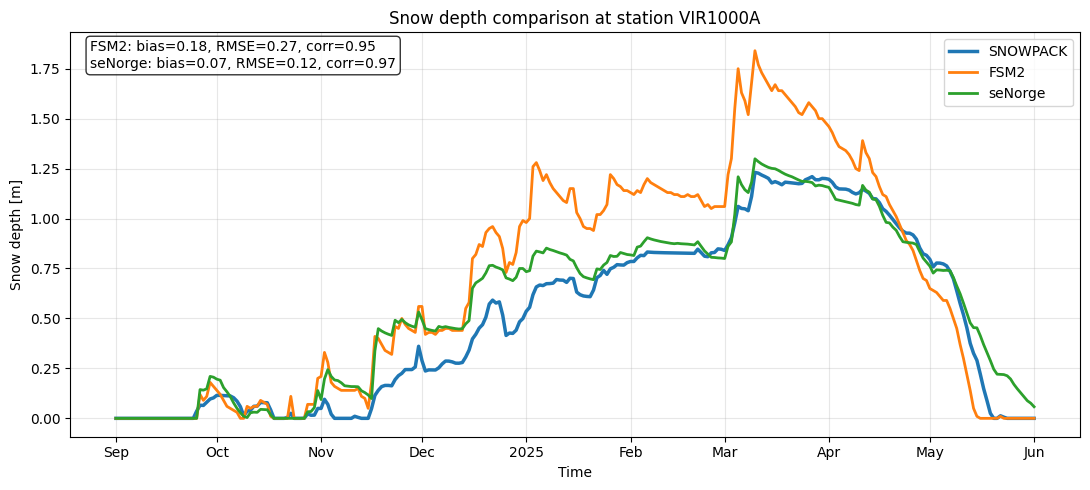

In [26]:
inspect_station("VIR1000A", snowpack_sd, fsm_sd, senorge_sd)

In [27]:
results_df.sort_values("rmse_fsm").head(10)

,station,elev,lon,lat,bias_fsm,rmse_fsm,corr_fsm,bias_senorge,rmse_senorge,corr_senorge,best_model_rmse,best_model_abs_bias
729,VIR965A,1569.0,7.831722,61.667069,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4456,VIR6158A,888.0,8.936055,61.738637,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4455,VIR6032A,913.0,8.882412,61.817294,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4457,VIR6381A,1119.0,9.054500,61.518747,0.001538,0.003922,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
728,VIR963A,1441.0,7.835868,61.649255,0.000441,0.004905,0.800713,-1.669792e-03,0.004508,0.816267,seNorge,FSM2
731,VIR976A,1478.0,7.808820,61.765041,0.005666,0.013347,0.977514,-9.443215e-07,0.002895,0.976967,seNorge,seNorge
3078,VIR3353A,628.0,8.453595,61.148775,-0.004787,0.021668,0.960322,1.253331e-01,0.199759,0.902518,FSM2,FSM2
4458,VIR6676A,922.0,9.193752,61.479750,-0.011121,0.029465,0.913097,-1.097386e-02,0.028597,0.922870,seNorge,seNorge
2769,VIR3041A,762.0,8.231672,61.831704,-0.013975,0.035220,0.943951,2.512150e-01,0.353813,0.795553,FSM2,FSM2
730,VIR975A,1519.0,7.810909,61.756134,0.018471,0.035325,0.983518,1.071445e-03,0.003553,0.987652,seNorge,seNorge


In [28]:
results_df.sort_values("rmse_fsm", ascending=False).head(10)

,station,elev,lon,lat,bias_fsm,rmse_fsm,corr_fsm,bias_senorge,rmse_senorge,corr_senorge,best_model_rmse,best_model_abs_bias
418,VIR454A,786.0,7.723727,61.562154,-0.914488,1.196344,0.804339,-0.955860,1.276034,0.740838,FSM2,FSM2
1318,VIR1570A,1752.0,8.048006,61.380827,0.981644,1.154049,0.976970,1.274746,1.415743,0.912595,FSM2,FSM2
1315,VIR1567A,1563.0,8.053965,61.354092,0.955490,1.129458,0.968930,1.212049,1.396402,0.829197,FSM2,FSM2
1228,VIR1480A,1622.0,8.029430,61.379872,0.908890,1.066877,0.975944,1.148302,1.296563,0.906872,FSM2,FSM2
1139,VIR1389A,1357.0,8.010856,61.378914,0.839591,1.011258,0.980181,0.738000,0.921907,0.865742,seNorge,seNorge
1413,VIR1668A,1471.0,8.058639,61.417426,0.837190,0.993678,0.969430,0.812953,0.992828,0.871727,seNorge,seNorge
760,VIR1008A,1171.0,7.913954,61.391906,-0.730991,0.977191,0.919873,-0.665422,0.928104,0.984853,seNorge,seNorge
22,VIR26A,1380.0,7.433330,61.898088,0.806446,0.958040,0.966605,1.214001,1.498214,0.804914,FSM2,FSM2
1054,VIR1304A,1323.0,7.998290,61.351223,0.768436,0.925285,0.975932,0.722728,0.880496,0.849949,seNorge,seNorge
1502,VIR1758A,1893.0,8.085160,61.382729,0.785562,0.897657,0.973647,0.765401,0.853649,0.959230,seNorge,seNorge


In [29]:
results_df.sort_values("rmse_senorge").head(10)

,station,elev,lon,lat,bias_fsm,rmse_fsm,corr_fsm,bias_senorge,rmse_senorge,corr_senorge,best_model_rmse,best_model_abs_bias
729,VIR965A,1569.0,7.831722,61.667069,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4455,VIR6032A,913.0,8.882412,61.817294,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4456,VIR6158A,888.0,8.936055,61.738637,0.000000,0.000000,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
4457,VIR6381A,1119.0,9.054500,61.518747,0.001538,0.003922,NaN,0.000000e+00,0.000000,NaN,seNorge,seNorge
731,VIR976A,1478.0,7.808820,61.765041,0.005666,0.013347,0.977514,-9.443215e-07,0.002895,0.976967,seNorge,seNorge
730,VIR975A,1519.0,7.810909,61.756134,0.018471,0.035325,0.983518,1.071445e-03,0.003553,0.987652,seNorge,seNorge
728,VIR963A,1441.0,7.835868,61.649255,0.000441,0.004905,0.800713,-1.669792e-03,0.004508,0.816267,seNorge,FSM2
4458,VIR6676A,922.0,9.193752,61.479750,-0.011121,0.029465,0.913097,-1.097386e-02,0.028597,0.922870,seNorge,seNorge
4364,VIR4651A,1030.0,8.666657,61.294062,0.100238,0.165866,0.980645,6.209564e-04,0.038555,0.988450,seNorge,seNorge
4365,VIR4652A,1004.0,8.664851,61.302985,0.120949,0.192379,0.984166,-1.514402e-03,0.038786,0.988209,seNorge,seNorge


In [30]:
results_df.sort_values("rmse_senorge", ascending=False).head(10)

,station,elev,lon,lat,bias_fsm,rmse_fsm,corr_fsm,bias_senorge,rmse_senorge,corr_senorge,best_model_rmse,best_model_abs_bias
766,VIR1014A,1819.0,7.901766,61.445357,0.497803,0.633942,0.987932,1.672683,1.897244,0.779091,FSM2,FSM2
586,VIR816A,1441.0,7.798414,61.647279,0.616389,0.756324,0.975677,1.520411,1.810344,0.820930,FSM2,FSM2
510,VIR740A,1583.0,7.785946,61.619570,0.486519,0.581805,0.982399,1.518132,1.764551,0.918521,FSM2,FSM2
509,VIR739A,1361.0,7.788029,61.610664,0.674895,0.850936,0.975192,1.331924,1.694286,0.784016,FSM2,FSM2
709,VIR941A,2075.0,7.881117,61.453290,0.555924,0.664893,0.981157,1.509428,1.692312,0.898770,FSM2,FSM2
637,VIR867A,1918.0,7.862505,61.452311,0.691389,0.789658,0.974515,1.481484,1.647071,0.944218,FSM2,FSM2
840,VIR1088A,1590.0,7.922404,61.437422,0.406491,0.531180,0.984556,1.427666,1.627263,0.828829,FSM2,FSM2
773,VIR1021A,1796.0,7.887485,61.507716,0.617429,0.731047,0.972208,1.424152,1.596696,0.926210,FSM2,FSM2
582,VIR812A,1584.0,7.806732,61.611654,0.660730,0.777672,0.976618,1.361274,1.572590,0.973701,FSM2,FSM2
2923,VIR3197A,1490.0,8.344924,61.485846,-0.330706,0.582482,0.971615,-1.357823,1.554334,0.984410,FSM2,FSM2
